In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter
from scipy.stats import zscore

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:
df = pd.read_csv('/content/spam_sms.csv', encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df = df.drop_duplicates()
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [3]:
print("Shape:", df.shape)
print("\nClass distribution:\n", df['label'].value_counts())
print("\nMissing values:\n", df.isnull().sum())

Shape: (5169, 3)

Class distribution:
 label
ham     4516
spam     653
Name: count, dtype: int64

Missing values:
 label        0
message      0
label_num    0
dtype: int64


Bar chart

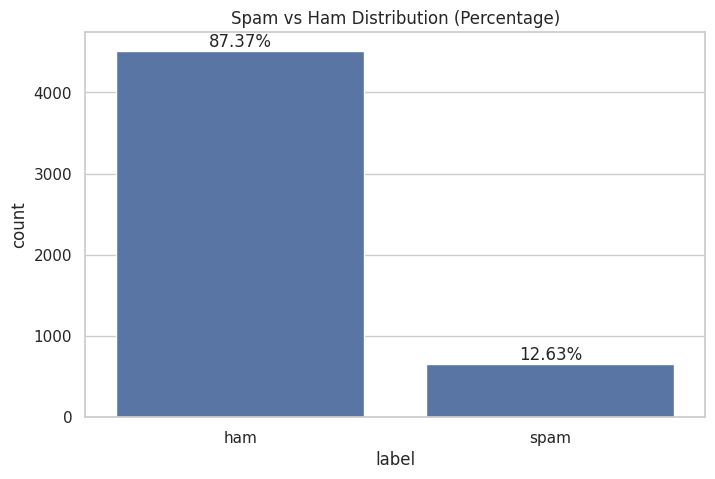

In [4]:
ax = sns.countplot(x='label', data=df)

total = len(df)
for p in ax.patches:
    ax.annotate(f'{p.get_height()/total:.2%}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Spam vs Ham Distribution (Percentage)")
plt.show()

In [9]:
df['length'] = df['message'].apply(len)

print(df.groupby('label')['length'].describe())

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.575952  56.396321   2.0   34.0   52.0   90.0  910.0
spam    653.0  138.738132  30.418104  13.0  132.0  149.0  158.0  226.0


Histogram with Kernel Density Estimate

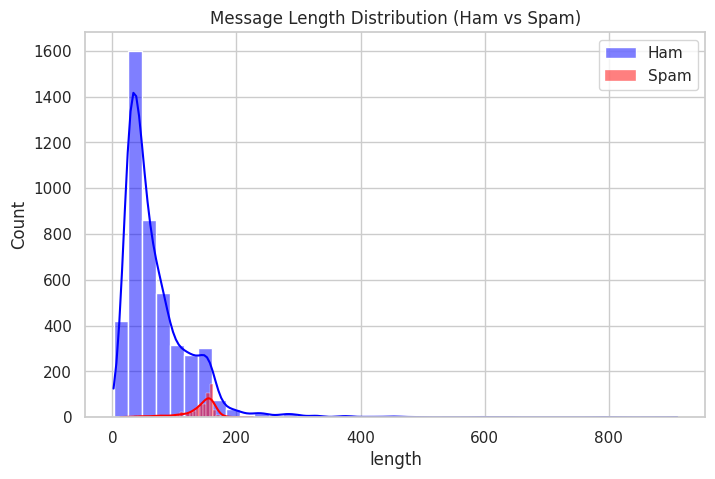

In [6]:
sns.histplot(df[df['label']=='ham']['length'], kde=True, label='Ham', color='blue', bins=40)
sns.histplot(df[df['label']=='spam']['length'], kde=True, label='Spam', color='red', bins=40)

plt.legend()
plt.title("Message Length Distribution (Ham vs Spam)")
plt.show()

Boxplot

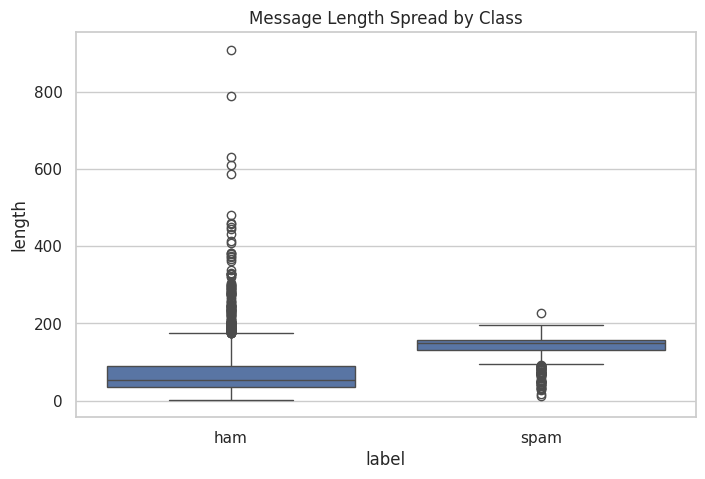

In [7]:
sns.boxplot(x='label', y='length', data=df)
plt.title("Message Length Spread by Class")
plt.show()

correlation heatmap

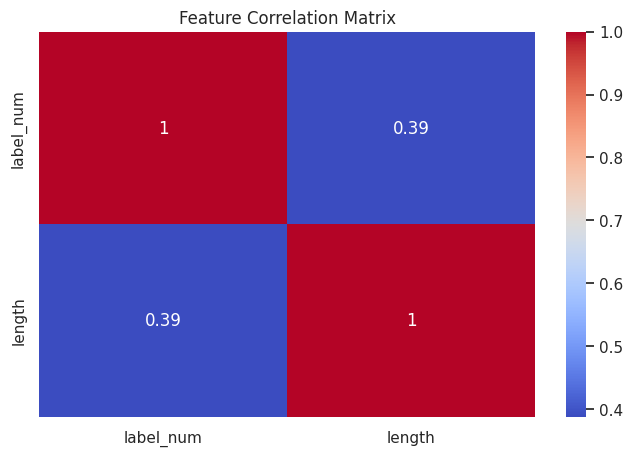

In [8]:
corr = df[['label_num', 'length']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [25]:
def get_words(text):
    return re.findall(r'\b\w+\b', text.lower())

spam_words, ham_words = [], []

for i in range(len(df)):
    words = get_words(df['message'].iloc[i])
    if df['label'].iloc[i] == 'spam':
        spam_words.extend(words)
    else:
        ham_words.extend(words)

spam_common = Counter(spam_words).most_common(15)
ham_common = Counter(ham_words).most_common(15)

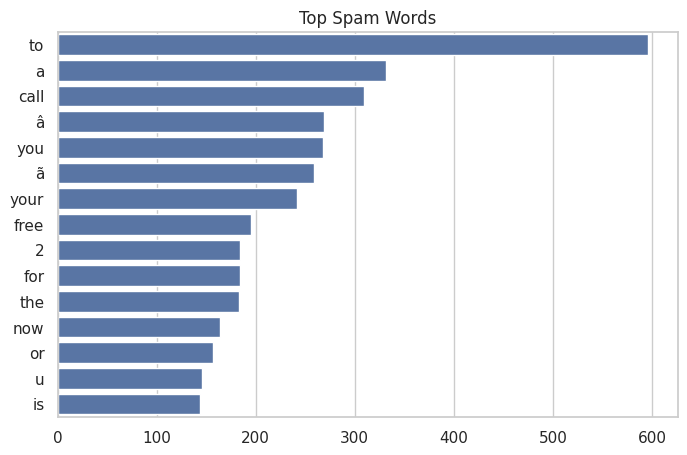

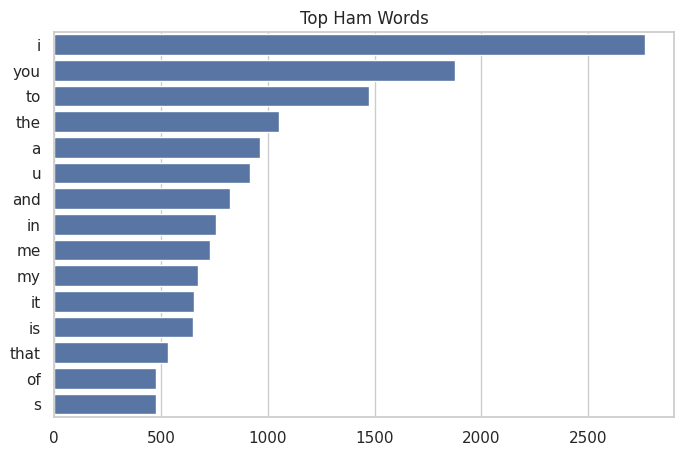

In [11]:
words, counts = zip(*spam_common)
sns.barplot(x=list(counts), y=list(words))
plt.title("Top Spam Words")
plt.show()

words, counts = zip(*ham_common)
sns.barplot(x=list(counts), y=list(words))
plt.title("Top Ham Words")
plt.show()

In [12]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.965183752417795
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.75      0.86       145

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



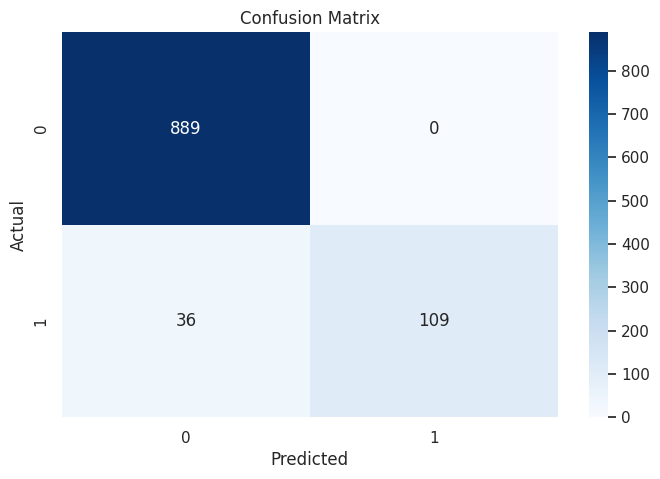

In [15]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Receiver Operating Characteristic curve

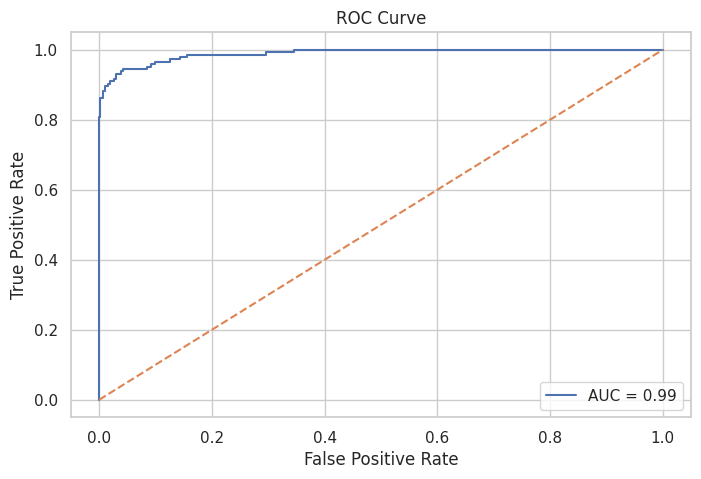

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [17]:
def rule_based_check(message):
    msg = message.lower()

    if re.search(r'(urgent|verify|suspended|account|bank|login)', msg) and \
       re.search(r'(http[s]?://|www\.|bit\.ly|\.com|\.net)', msg):
        return True

    spam_keywords = ["win","free","prize","cash","offer","click","buy","claim","reward"]

    score = sum(word in msg for word in spam_keywords)

    if "!" in msg: score += 1
    if "$" in msg: score += 1
    if any(char.isdigit() for char in msg): score += 1
    if re.search(r'http', msg): score += 2

    return score >= 2

In [28]:
def check_spam(message):

    if rule_based_check(message):
        print("Spam detected (Rule-Based)")
        return

    vec = vectorizer.transform([message])
    pred = model.predict(vec)[0]

    if pred == 1:
        print("Spam detected (ML Model)")
    else:
        print("Normal message")

user_input = input("Enter message: ")
check_spam(user_input)

Enter message: abcde
Normal message
